# **Análise Exploratória de Dados**

## Informações do conjunto de dados:

## Importação das bibliotecas

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## Carregando o conjunto de dados

In [21]:
df_avaliacoes = pd.read_csv('../data/raw/avaliacoes.csv')
df_clientes = pd.read_csv('../data/raw/clientes.csv')
df_geolocalizacao = pd.read_csv('../data/raw/geolocalizacao.csv')
df_itens_pedidos = pd.read_csv('../data/raw/itens_pedidos.csv')
df_pagamentos = pd.read_csv('../data/raw/pagamentos.csv')
df_pedidos = pd.read_csv('../data/raw/pedidos.csv')
df_produtos = pd.read_csv('../data/raw/produtos.csv')
df_tabela_auxiliar = pd.read_csv('../data/raw/tabela_auxiliar.csv')
df_vendedores = pd.read_csv('../data/raw/vendedores.csv')

## Entendendo o conjunto de dados

In [22]:
def resumo_tabelas(tabelas):
    for nome, tabela in tabelas.items():
        linhas, colunas = tabela.shape
        nulos = tabela.isnull().sum()
        nulos_total = nulos.sum()
        duplicatas = tabela.duplicated().sum()

        print(f'\n{"="*150}')
        print(f'  TABELA: {nome.upper()}')
        print(f'{"="*150}')
        print(f'  Linhas      : {linhas}')
        print(f'  Colunas     : {colunas}')
        print(f'  Nulos       : {nulos_total} ({round(nulos_total / (linhas * colunas) * 100, 1)}% do total)')
        print(f'  Duplicatas  : {duplicatas} ({round(duplicatas / linhas * 100, 1)}% das linhas)')

    
        if nulos_total > 0:
            print(f'\n  Nulos por coluna:')
            for col, qtd in nulos[nulos > 0].items():
                print(f'    • {col}: {qtd} ({round(qtd / linhas * 100, 1)}%)')
    
        print(f'  Colunas     : {list(tabela.columns)}')
    
        print(f'\n  Primeiras 5 linhas:')
        display(tabela.head(5))
        print(f'  Últimas 5 linhas:')
        display(tabela.tail(5))
        print(f'  5 linhas aleatórias:')
        display(tabela.sample(5))
        print(f'  Tipos de dados:')
        display(tabela.dtypes)
        print(f'  Memória utilizada por coluna:')
        display(tabela.memory_usage(deep=True))
        print()

In [23]:
tabelas = {
    'df_avaliacoes': df_avaliacoes,
    'df_clientes': df_clientes,
    'df_geolocalizacao': df_geolocalizacao,
    'df_itens_pedidos': df_itens_pedidos,
    'df_pagamentos': df_pagamentos,
    'df_pedidos': df_pedidos,
    'df_produtos': df_produtos,
    'df_tabela_auxiliar': df_tabela_auxiliar,
    'df_vendedores': df_vendedores
}

resumo_tabelas(tabelas)


  TABELA: DF_AVALIACOES
  Linhas      : 99224
  Colunas     : 7
  Nulos       : 145903 (21.0% do total)
  Duplicatas  : 0 (0.0% das linhas)

  Nulos por coluna:
    • review_comment_title: 87656 (88.3%)
    • review_comment_message: 58247 (58.7%)
  Colunas     : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

  Primeiras 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


  Últimas 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49


  5 linhas aleatórias:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
2124,89f69225956f951295ca4c7fb1266553,27700,vassouras,RJ
939,2fb25ab44bdbeae6a4d816e0d0c9d500,27274,volta redonda,RJ
104,698624c6632eeba1774924dbea24c700,1425,sao paulo,SP
568,ddd51ae8cda92f3995a51fc0f0f3eec7,23062,rio de janeiro,RJ
1071,0ff83046c3fa22efee8ecf291888b191,95110,caxias do sul,RS


  Tipos de dados:


seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

  Memória utilizada por coluna:


Index                        132
seller_id                 123800
seller_zip_code_prefix     24760
seller_city                56230
seller_state               30950
dtype: int64

## Tratamento dos tipos de dados|

In [24]:
df_avaliacoes = df_avaliacoes.astype({
    'review_id':'string',
    'order_id':'string',
    'review_score':'Int8',
    'review_comment_title':'string',
    'review_comment_message':'string',
})
for col in ['review_creation_date', 'review_answer_timestamp']:
    df_avaliacoes[col] = pd.to_datetime(df_avaliacoes[col])

df_clientes = df_clientes.astype({
    'customer_id':'string',
    'customer_unique_id':'string',
    'customer_zip_code_prefix':'string',
    'customer_city':'category',
    'customer_state':'category',
})


df_geolocalizacao = df_geolocalizacao.astype({
    'geolocation_zip_code_prefix':'string',
    'geolocation_lat':'float32',
    'geolocation_lng':'float32',
    'geolocation_city':'category',
    'geolocation_state':'category',
})

df_itens_pedidos = df_itens_pedidos.astype({
    'order_id':'string',
    'order_item_id':'Int64',
    'product_id':'string',
    'seller_id':'string',
    'price':'float32',
    'freight_value':'float32',
})
df_itens_pedidos['shipping_limit_date'] = pd.to_datetime(df_itens_pedidos['shipping_limit_date'])

df_pagamentos = df_pagamentos.astype({
    'order_id':'string',
    'payment_sequential':'Int8',
    'payment_type':'category',
    'payment_installments':'Int8',
    'payment_value':'float32',
})

df_pedidos = df_pedidos.astype({
    'order_id':'string',
    'customer_id':'string',
    'order_status':'category',
})
for col in [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])

df_produtos = df_produtos.astype({
    'product_id':'string',
    'product_category_name':'category',
    'product_name_lenght':'Int16',
    'product_description_lenght':'Int32',
    'product_photos_qty':'Int8',
    'product_weight_g':'float32',
    'product_length_cm':'float32',
    'product_height_cm':'float32',
    'product_width_cm':'float32',
})

df_tabela_auxiliar = df_tabela_auxiliar.astype({
    'product_category_name':'category',
    'product_category_name_english':'category',
})

df_vendedores = df_vendedores.astype({
    'seller_id':'string',
    'seller_zip_code_prefix':'string',
    'seller_city':'category',
    'seller_state':'category',
})

Como o objetivo é entender a relação entre notas e comentários, vamos focar na tabela de avaliações.

## Tabela de avaliações

In [25]:
tabelas = {
    'df_avaliacoes': df_avaliacoes,
}

resumo_tabelas(tabelas)


  TABELA: DF_AVALIACOES
  Linhas      : 99224
  Colunas     : 7
  Nulos       : 145903 (21.0% do total)
  Duplicatas  : 0 (0.0% das linhas)

  Nulos por coluna:
    • review_comment_title: 87656 (88.3%)
    • review_comment_message: 58247 (58.7%)
  Colunas     : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

  Primeiras 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,<NA>,<NA>,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,<NA>,<NA>,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,<NA>,<NA>,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,<NA>,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,<NA>,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


  Últimas 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,<NA>,<NA>,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,<NA>,<NA>,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,<NA>,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,<NA>,<NA>,2018-07-01,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,<NA>,"meu produto chegou e ja tenho que devolver, po...",2017-07-03,2017-07-03 21:01:49


  5 linhas aleatórias:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
77094,0191cf9d15d7059499c362496486b7f7,08d3b6ee17b7cb32e530f4488c3f6abf,4,<NA>,<NA>,2018-08-04,2018-08-08 17:59:04
43684,465227a40cf28e784b6d9e1da08ce9e3,b9ae8347ff0acee82f6bc8eea0067eb8,5,<NA>,<NA>,2017-11-02,2017-11-13 12:58:54
24742,cc79f9048fcc271643166b8db448db5f,bfd664f7724709fb7bfbb33308a64ccd,5,ÓTIMO,ÓTIMO,2018-01-16,2018-05-18 17:09:43
83585,b4dffda6cbf1a5a615b2a8f146bdbddd,8df2feeda535c3b57a1e8fd9bbb9e95c,5,<NA>,<NA>,2017-10-20,2017-10-20 22:46:35
11817,8cc6e06c98e686406c863f202db4598d,da9713f62e0d54668895dd0ca6ddbb64,4,<NA>,<NA>,2018-06-13,2018-06-13 21:33:57


  Tipos de dados:


review_id                          string
order_id                           string
review_score                         Int8
review_comment_title               string
review_comment_message             string
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

  Memória utilizada por coluna:


Index                          132
review_id                  3968960
order_id                   3968960
review_score                198448
review_comment_title        947467
review_comment_message     3671710
review_creation_date        793792
review_answer_timestamp     793792
dtype: int64

## Unindo as variáveis `review_comment_title` e `review_comment_message`

In [26]:
# unindo as variáveis `review_comment_title` e `review_comment_message` em uma nova coluna `review_comment_full`
df_avaliacoes['review_comment'] = df_avaliacoes['review_comment_title'].fillna('') + ' ' + df_avaliacoes['review_comment_message'].fillna('')

In [27]:
df_avaliacoes.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
18958,7bf4550966295d9aaafdc486dc4c7f99,985f418428a2040e904e93491b78c1f1,3,<NA>,Recebi a metade do pedido. Nao recebi o lustre...,2018-03-08,2018-03-10 20:07:22,Recebi a metade do pedido. Nao recebi o lustr...
56018,8f2076c507e8f0288700f01a1a1d83dc,8031adfac87d3fb5ff7b41a0342aae74,1,<NA>,<NA>,2017-10-01,2017-10-04 22:03:12,
40951,dad2cc44b8da589b82377a271a4e3d37,814a581bb15822a49e046f3f612e18e0,4,<NA>,<NA>,2017-11-28,2017-11-28 17:22:34,
81816,d1dc027594a6813d28d07260bd09d652,08ae4b03138c7c51262c05f8f6e58b74,5,<NA>,<NA>,2018-05-19,2018-05-22 09:21:54,
32481,9acbd93ab5847de6f6a084b4fd3394cb,a51cf85ecb6bb335d21abd348a85acd3,4,<NA>,<NA>,2017-05-11,2017-05-11 21:39:35,
36150,b578a522fa08f8a3ed0a335f58c979c2,6709606f3773c59d8bed53c0d9bb614d,1,Luminárias,"O produto veio faltando uma unidade, e ainda n...",2018-06-09,2018-06-09 16:44:08,Luminárias O produto veio faltando uma unidade...
39354,f53f5e29a73b825d7b5e37d1dd6e7b84,b1886110c1ae28ae4f81d9bc674b4384,5,<NA>,Excelente compra!,2018-01-23,2018-01-24 21:12:17,Excelente compra!
63019,f3445275b06390e813a929db9b4dc9e6,d49f3ce01bf8ca94897ccf96b1e4f45c,5,<NA>,<NA>,2017-09-24,2017-09-26 22:16:57,
82902,de1af2f76f7b5294ddc978735d788aea,26748c2a309fe92bbe436c13ff82ff36,5,<NA>,<NA>,2018-03-24,2018-03-28 00:48:14,
53599,243041c432092086a0149ba44d28e96b,389d99caa7584786ee8a27df1638f6ad,4,<NA>,<NA>,2017-07-15,2017-07-16 01:00:50,


## Removendo comentários vazios

In [28]:
df_avaliacoes_limpo = df_avaliacoes[df_avaliacoes['review_comment'] != ' ']

In [29]:
df_avaliacoes_limpo.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
75816,d4c8139c67d9afcdf152bea48125bf1b,a19b7b1cfd5954c32d0c1cf396c9c951,5,Kit bolsas maternidade,Muito Lindas É muito funcifuncional 👏😍,2018-05-05,2018-05-06 13:01:19,Kit bolsas maternidade Muito Lindas É muito f...
96111,8f9916a19f1b3f741dd3489a30ac37df,741219cefb77a5c6acbbecafb6d0e6f5,5,Bom produto - Recomendo!,"Cartucho com maior capacidade, está cumprindo ...",2018-07-21,2018-08-05 19:20:37,Bom produto - Recomendo! Cartucho com maior ca...
36991,ec43768e3d2cb4c9d3d9e6709a4f9200,c4a4340f8f35d5289ea5eb4dd44815f4,1,<NA>,Eu comprei 2 produtos: uma máscara do Hulk e u...,2017-11-05,2017-11-07 19:14:04,Eu comprei 2 produtos: uma máscara do Hulk e ...
34987,0ebd2390225947d5549f683303018752,fd7b969d5c0e4e9fd1b64259682a2aa0,5,<NA>,Entregue conforme combinado.,2018-02-16,2018-02-25 04:10:20,Entregue conforme combinado.
29867,ab2635060962238eb19c2e2813c9f162,b88187e3e61e2aa58b398415c2d2d4cc,5,Otimo,Rápido e de ótima qualidade,2018-07-26,2018-07-26 19:06:10,Otimo Rápido e de ótima qualidade
9911,a492b3efc47eb9096c41de9d772cc4f3,b985389048e8bbb41d4993f4bd86f47f,1,<NA>,Ainda não recebi,2017-09-22,2017-09-25 22:08:27,Ainda não recebi
28569,268fe3c6b00758e3a602f8cd3ed93c1f,faeb0ac7f6e1480f3dd14e5cd802dc8a,1,<NA>,Comprei um produto e recebi outro e inferior.\...,2018-02-07,2018-02-07 22:53:40,Comprei um produto e recebi outro e inferior....
93464,f2c00b086716c9942b9387f9aa7008ed,b13a218f04f34967574a5a8ff1d07859,4,<NA>,Muito bom mais o cabo e de plástico poderia se...,2017-12-17,2017-12-20 14:46:43,Muito bom mais o cabo e de plástico poderia s...
65873,4afaedad28ad2d549b9d2078736c6aeb,9c78e72b5160190f45195d6ecf7875dc,1,0,Sempre comprei na lannister e não tive problem...,2018-08-25,2018-08-27 12:14:13,0 Sempre comprei na lannister e não tive probl...
78557,103fbe80b510033507349054e169e18a,24843df655e56c3713485a7880677287,2,<NA>,"Recebi o produto dia 01/12/2017, 6ª feira, por...",2017-12-02,2017-12-05 11:54:10,"Recebi o produto dia 01/12/2017, 6ª feira, po..."


## Removendo letras maiúsculas e pontuações

In [30]:
df_avaliacoes_limpo['review_comment'] = df_avaliacoes['review_comment'].str.lower()

In [31]:
import string

df_avaliacoes_limpo['review_comment'] = df_avaliacoes_limpo['review_comment'].str.translate(str.maketrans('', '', string.punctuation))

In [32]:
df_avaliacoes_limpo.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
51307,678e90e021dc9313e6c95d6bfb1b20d7,e5daa600c317dd1854619b456f89fc1b,2,Vou avaliar na instalação,O produto ainda não foi instalado,2018-07-03,2018-07-03 18:15:09,vou avaliar na instalação o produto ainda não ...
88650,02d9a2a7e641ca7c6d6c7a58d79e2c9e,478e6ea13625ffcbd107d95b614d79b1,5,<NA>,Produto com qualidade boa,2017-12-06,2017-12-06 20:54:19,produto com qualidade boa
34290,44a081adf6d642ae5daf65305889e5e7,a96197cd3594ecdabaeda0841d5a63fd,5,<NA>,Excelente serviço !! Todas etapas perfeitas no...,2017-05-05,2017-05-06 00:16:42,excelente serviço todas etapas perfeitas no ...
58683,98c303ce6a5deb174c7a4b76c882d940,03b936f126145f2bb36600400aedb13a,1,<NA>,Produto comprado e não entregue no prazo. O fo...,2018-03-16,2018-03-16 12:46:42,produto comprado e não entregue no prazo o fo...
81532,c4c25a0f0c2c24aeb962ca4c310d5501,31732ac03c3866969643e70e4a4a633c,5,<NA>,Foi entregue muito antes do previsto.,2017-06-10,2017-06-13 13:44:05,foi entregue muito antes do previsto
70310,e9c244e3880677b5e427c7970c6928b2,f807d9018684b10d06ca569cdd62c0af,1,Compra kit maria escandal,Estou em dúvida se é um produto original o kit...,2018-06-15,2018-06-16 01:01:25,compra kit maria escandal estou em dúvida se é...
97972,cba941af24fda570a92e9182bf90fa1c,3f1ba9515b44ee835d8fcb64238f0b27,5,Excelente,Relógio município e entrega rápida. Recomendo,2018-05-05,2018-05-06 00:20:38,excelente relógio município e entrega rápida ...
76323,4adee6ec19eac0c58bff8f61ce8d5561,b787096bc96d359f4bacc2f80047c2af,5,<NA>,ótimo produto.\r\nchegou bem rápido .\r\nem me...,2017-07-07,2017-07-13 12:36:36,ótimo produto\r\nchegou bem rápido \r\nem men...
13481,92384c04aefb6cb1e0947b5ec91681b0,0f537c28b416c542bd58984e8d51b4ef,5,<NA>,"entrega rapida e tudo ok com o produto, recomendo",2017-10-29,2017-10-30 20:00:15,entrega rapida e tudo ok com o produto recomendo
75601,f207c376fad3e099bf6aedb8535fc387,50ff05d6d0da8a197889efe41244b0ee,3,<NA>,bom,2017-11-07,2018-01-11 16:40:01,bom


## Removendo variáveis desnecessárias

In [33]:
avaliacoes = df_avaliacoes_limpo.copy()

avaliacoes = avaliacoes.drop(columns=['review_id', 'order_id', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'])

In [34]:
avaliacoes.sample(10)

,review_score,review_comment
24153,5,entrega muito antes do previsão produto na va...
88475,5,filtra muito bematendeu minhas expectativas
525,1,ainda não recebi
9085,5,satisfeita sabonetes de ótima qualidade recomendo
35814,5,10 entrega muito rapida
51637,5,recomendo excelente produto
69077,5,amei a mochila e como veio rápido e mto bem e...
19067,5,produto entregue antes do prazo recomendo
70538,5,super recomendado
61534,4,muito bom produto entregue dentro do prazo e e...


## Distribuição das notas

In [38]:
def classificar_sentimento(score):
    if score == 5: return 'Muito Positivo'
    elif score == 4: return 'Positivo'
    elif score == 3: return 'Neutro'
    elif score == 2: return 'Negativo'
    else: return 'Muito Negativo'

avaliacoes['review_label'] = avaliacoes['review_score'].apply(classificar_sentimento)
display(avaliacoes.head(10))

,review_score,review_comment,review_label
3,5,recebi bem antes do prazo estipulado,Muito Positivo
4,5,parabéns lojas lannister adorei comprar pela ...,Muito Positivo
9,4,recomendo aparelho eficiente no site a marca d...,Positivo
12,4,mas um pouco travandopelo valor ta boa\r\n,Positivo
15,5,super recomendo vendedor confiável produto ok ...,Muito Positivo
16,2,gostaria de saber o que houve sempre recebi e...,Negativo
19,1,não chegou meu produto péssimo,Muito Negativo
22,5,ótimo loja nota 10,Muito Positivo
24,5,obrigado pela atençao amim dispensada,Muito Positivo
27,5,a compra foi realizada facilmente\r\na entreg...,Muito Positivo


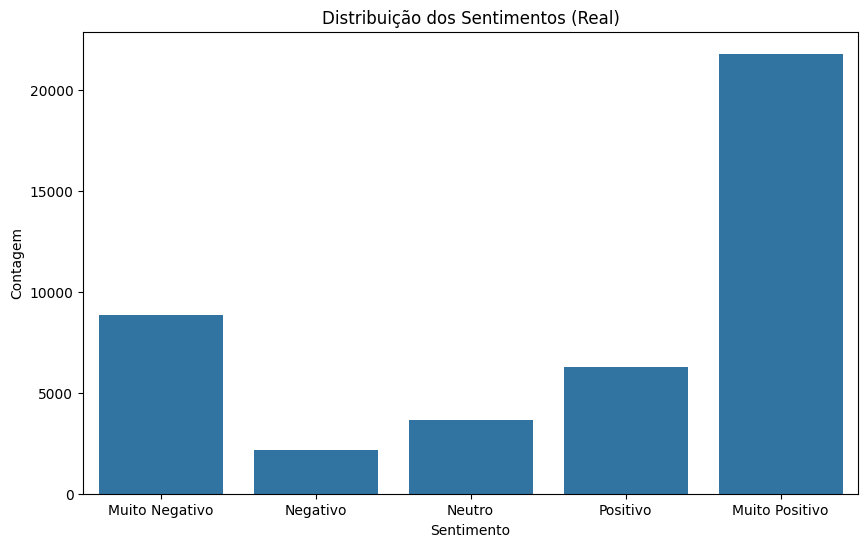

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='review_label', data=avaliacoes, order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'])
plt.title('Distribuição dos Sentimentos (Real)')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.show()

## Exportando o conjunto de dados

In [41]:
avaliacoes.to_parquet("avaliacoes.parquet", index=False)